# Traffic Sign Detection & Classification

In [1]:
# Run this once if packages are missing
%pip install numpy matplotlib pillow scipy ipywidgets
!mamba install scikit-learn
!mamba install opencv

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from IPython.display import display, clear_output
import time

print("OpenCV:", cv2.__version__)


mambajs 0.21.4

Process pip requirements ...

Requirement numpy already handled by conda/micromamba/mamba.
Requirement matplotlib already handled by conda/micromamba/mamba.
Requirement pillow already handled by conda/micromamba/mamba.
Requirement scipy already handled by conda/micromamba/mamba.
Requirement ipywidgets already handled by conda/micromamba/mamba.
mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 0.840 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.7.22  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.5.1      pyhd8ed1ab_0         conda-forge
+ idna                3.20       pyh5ded981_0         conda-forge
+ joblib            

## 1. Dataset

In [2]:
DATASET_DIR = "dataset"

SIGNS = {
    0: "NOT A SIGN",
    1: "STOP",
    2: "TURN LEFT",
    3: "TURN RIGHT",
    4: "DO NOT TURN LEFT",
    5: "DO NOT TURN RIGHT",
    6: "ONE WAY",
    7: "SPEED LIMIT",
    8: "OTHER", 9: "OTHER", 10: "OTHER", 11: "OTHER", 12: "OTHER"
}

if not os.path.isdir(DATASET_DIR):
    raise FileNotFoundError(
        f"Dataset folder not found: {DATASET_DIR}. Put the dataset folder beside this notebook."
    )

CLASS_IDS = sorted([int(x) for x in os.listdir(DATASET_DIR)
                    if x.isdigit() and os.path.isdir(os.path.join(DATASET_DIR, x))])
print("Classes found:", CLASS_IDS)
print("Number of classes:", len(CLASS_IDS))


Classes found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Number of classes: 13


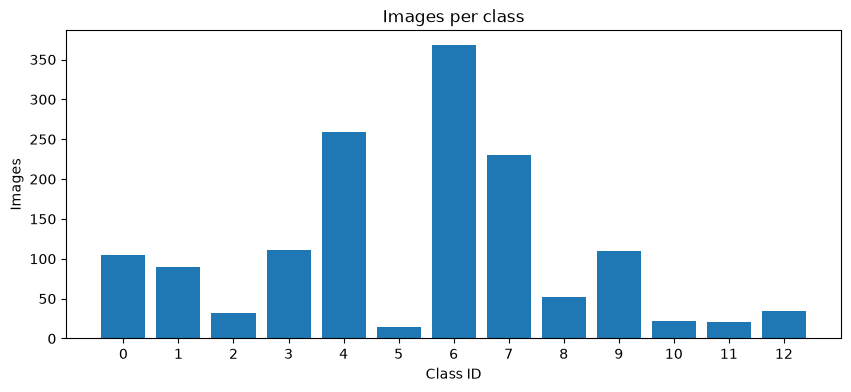

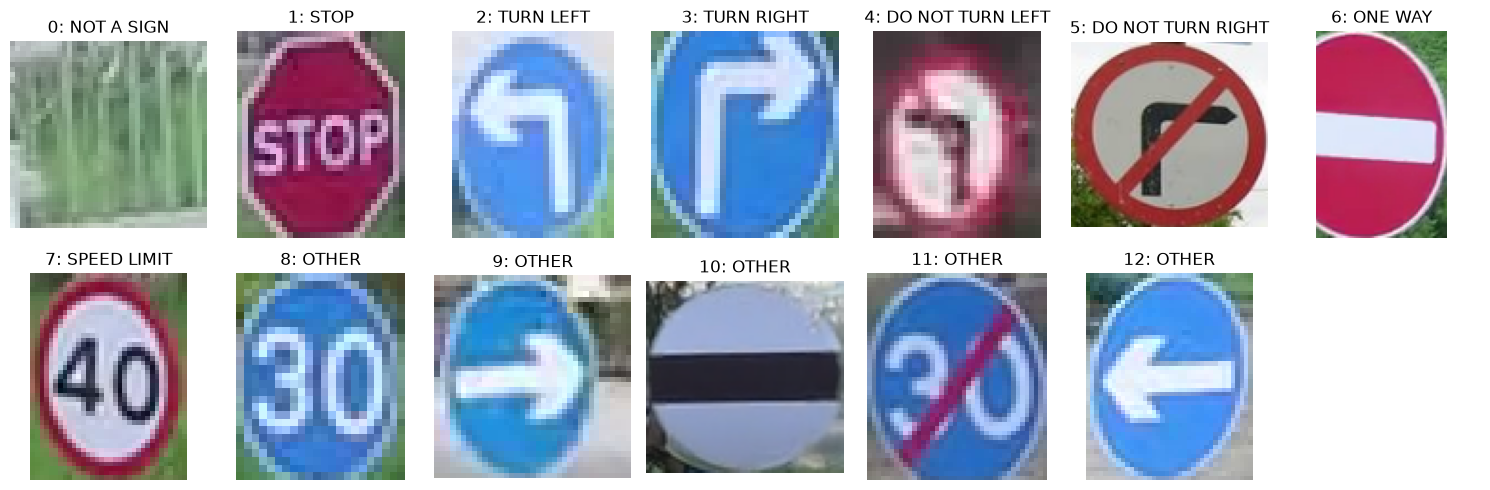

In [3]:
# Count images and display examples
counts = {}
for cid in CLASS_IDS:
    folder = os.path.join(DATASET_DIR, str(cid))
    counts[cid] = len([f for f in os.listdir(folder) if f.lower().endswith((".png", ".jpg", ".jpeg"))])

plt.figure(figsize=(10,4))
plt.bar([str(x) for x in CLASS_IDS], [counts[x] for x in CLASS_IDS])
plt.xlabel("Class ID"); plt.ylabel("Images"); plt.title("Images per class"); plt.show()

fig, axes = plt.subplots(2, 7, figsize=(15,5))
for ax, cid in zip(axes.flat, CLASS_IDS):
    files = [f for f in os.listdir(os.path.join(DATASET_DIR, str(cid))) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
    if files:
        img = cv2.imread(os.path.join(DATASET_DIR, str(cid), files[0]))
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{cid}: {SIGNS.get(cid, 'OTHER')}"); ax.axis("off")
for ax in axes.flat[len(CLASS_IDS):]: ax.axis("off")
plt.tight_layout(); plt.show()


## 2. Load and prepare the training data

Each image is resized to 32×32, converted to grayscale, deskewed, and converted to HOG features.

In [4]:
IMAGE_SIZE = 32

def load_dataset(dataset_dir):
    images, labels = [], []
    for cid in CLASS_IDS:
        folder = os.path.join(dataset_dir, str(cid))
        for name in os.listdir(folder):
            if not name.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            path = os.path.join(folder, name)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                images.append(cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE)))
                labels.append(cid)
    return np.array(images), np.array(labels, dtype=np.int32)

def deskew(img):
    m = cv2.moments(img)
    if abs(m["mu02"]) < 1e-2:
        return img.copy()
    skew = m["mu11"] / m["mu02"]
    M = np.float32([[1, skew, -0.5 * IMAGE_SIZE * skew], [0, 1, 0]])
    return cv2.warpAffine(img, M, (IMAGE_SIZE, IMAGE_SIZE),
                          flags=cv2.WARP_INVERSE_MAP | cv2.INTER_LINEAR)

def make_hog():
    return cv2.HOGDescriptor(
        _winSize=(20,20), _blockSize=(10,10), _blockStride=(5,5),
        _cellSize=(10,10), _nbins=9, _derivAperture=1, _winSigma=-1,
        _histogramNormType=0, _L2HysThreshold=0.2, _gammaCorrection=True,
        _nlevels=64, _signedGradient=True)

images, labels = load_dataset(DATASET_DIR)
print("Images:", len(images))
print("Image shape:", images.shape)

hog = make_hog()
features = np.array([hog.compute(deskew(img)).ravel() for img in images], dtype=np.float32)
print("HOG feature shape:", features.shape)


Images: 1449
Image shape: (1449, 32, 32)
HOG feature shape: (1449, 324)


## 3. Train the SVM classifier

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.20, random_state=42, stratify=labels
)

svm = cv2.ml.SVM_create()
svm.setType(cv2.ml.SVM_C_SVC)
svm.setKernel(cv2.ml.SVM_RBF)
svm.setC(12.5)
svm.setGamma(0.50625)
svm.train(X_train, cv2.ml.ROW_SAMPLE, y_train)

# Save model so webcam detection can be run later without retraining
svm.save("traffic_sign_svm.dat")

y_pred = svm.predict(X_test)[1].ravel().astype(int)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy*100:.2f}%")
print("\nClassification report:")
print(classification_report(y_test, y_pred, labels=CLASS_IDS,
                            target_names=[SIGNS.get(i, str(i)) for i in CLASS_IDS],
                            zero_division=0))


Test accuracy: 95.52%

Classification report:
                   precision    recall  f1-score   support

       NOT A SIGN       0.62      1.00      0.76        21
             STOP       1.00      0.89      0.94        18
        TURN LEFT       1.00      0.67      0.80         6
       TURN RIGHT       1.00      1.00      1.00        22
 DO NOT TURN LEFT       1.00      0.96      0.98        52
DO NOT TURN RIGHT       0.00      0.00      0.00         3
          ONE WAY       1.00      0.99      0.99        74
      SPEED LIMIT       1.00      0.96      0.98        46
            OTHER       1.00      1.00      1.00        11
            OTHER       1.00      0.95      0.98        22
            OTHER       1.00      1.00      1.00         4
            OTHER       1.00      1.00      1.00         4
            OTHER       1.00      1.00      1.00         7

         accuracy                           0.96       290
        macro avg       0.89      0.88      0.88       290
     wei

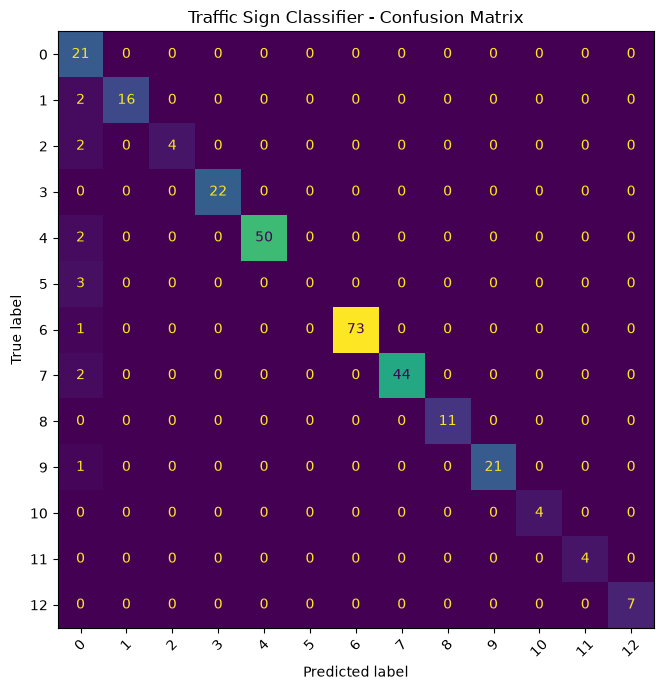

In [6]:
cm = confusion_matrix(y_test, y_pred, labels=CLASS_IDS)
fig, ax = plt.subplots(figsize=(9,7))
ConfusionMatrixDisplay(cm, display_labels=CLASS_IDS).plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title("Traffic Sign Classifier - Confusion Matrix")
plt.tight_layout(); plt.show()


## 4. Sign detection from a camera frame

In [7]:
def color_mask(frame):
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # Red signs: two HSV ranges
    red1 = cv2.inRange(hsv, np.array([0, 70, 50]), np.array([10, 255, 255]))
    red2 = cv2.inRange(hsv, np.array([170, 70, 50]), np.array([180, 255, 255]))
    # Blue signs
    blue = cv2.inRange(hsv, np.array([90, 70, 50]), np.array([135, 255, 255]))

    mask = cv2.bitwise_or(red1, red2)
    mask = cv2.bitwise_or(mask, blue)

    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask

def detect_sign_region(frame):
    mask = color_mask(frame)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    h, w = frame.shape[:2]
    best = None
    best_score = 0

    for contour in contours:
        x, y, bw, bh = cv2.boundingRect(contour)
        area = cv2.contourArea(contour)
        box_area = bw * bh
        if box_area == 0: continue
        if bw < 30 or bh < 30: continue
        if bw > 0.8*w or bh > 0.8*h: continue

        aspect = bw / float(bh)
        fill = area / float(box_area)
        if not (0.5 <= aspect <= 1.5): continue
        if fill < 0.35: continue

        score = area
        if score > best_score:
            best_score = score
            best = (x, y, bw, bh)

    return best, mask

def classify_crop(crop):
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (IMAGE_SIZE, IMAGE_SIZE))
    gray = deskew(gray)
    feature = hog.compute(gray).reshape(1, -1).astype(np.float32)
    return int(svm.predict(feature)[1][0][0])

def detect_and_classify(frame):
    output = frame.copy()
    box, mask = detect_sign_region(frame)
    result = None

    if box is not None:
        x, y, w, h = box
        pad = int(0.15 * max(w, h))
        x1, y1 = max(0, x-pad), max(0, y-pad)
        x2, y2 = min(frame.shape[1], x+w+pad), min(frame.shape[0], y+h+pad)
        crop = frame[y1:y2, x1:x2]

        if crop.size:
            cid = classify_crop(crop)
            label = SIGNS.get(cid, f"CLASS {cid}")
            cv2.rectangle(output, (x1,y1), (x2,y2), (0,255,0), 2)
            cv2.putText(output, label, (x1, max(30,y1-10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0,255,0), 2)
            result = (cid, label, crop)

    return output, mask, result


## 5. Test on one image


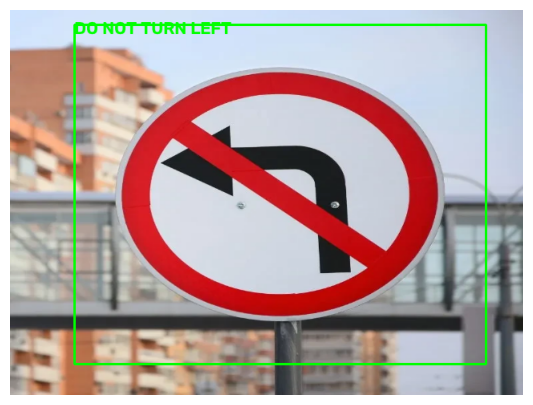

Prediction: DO NOT TURN LEFT


In [10]:
TEST_IMAGE = "images1.jpg"
if os.path.exists(TEST_IMAGE):
    img = cv2.imread(TEST_IMAGE)
    img = cv2.resize(img, (640, 480))
    out, mask, result = detect_and_classify(img)
    plt.figure(figsize=(10,5))
    plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()
    print("Prediction:", result[1] if result else "No sign detected")
else:
    print(f"Add a test image named '{TEST_IMAGE}' or change TEST_IMAGE.")


## 6. Webcam traffic-sign detection

In [13]:
def run_webcam(camera_index=0, width=640, height=480):
    cap = cv2.VideoCapture(camera_index)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, width)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, height)

    if not cap.isOpened():
        print("ERROR: Webcam could not be opened.")
        print("Check camera permissions and camera_index (try 1 if you have multiple cameras).")
        return

    print("Webcam started. Press Q in the camera window to stop.")
    while True:
        ok, frame = cap.read()
        if not ok:
            print("Could not read a frame from the webcam.")
            break

        frame = cv2.flip(frame, 1)
        output, mask, result = detect_and_classify(frame)

        cv2.imshow("Traffic Sign Detection - Press Q to quit", output)

        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

run_webcam(0)


ERROR: Webcam could not be opened.
Check camera permissions and camera_index (try 1 if you have multiple cameras).
